### 앙케트 분석을 위한 자연어 처리

앙케트나 sns 등 인터넷이 활성화된 요즘 문장 데이터에 많은 정보가 담겨 있습니다. 그리고 이 정보를 활용하기 위해서는 앞장의 이미지 처리와 마찬가지로 문장을 수치화하고 컴퓨터가 이해할 수 있는 형태로 만들어야 합니다.   
   
이 때 필요한 것이 '자연어 처리(NLP, Natural Language Processing)' 기술입니다.         
          
예를 들어 고객으로부터 설문 결과를 받은 경우, 입력받은 문장에서 필요한 정보를 뽑아내고 카테고리화하고 그것을 분석해 설문조사 정보를 활용할 수 있습니다. 이와 같은 정보의 추출이나 정리 작업을 사람 한 명이 하면 처리해야 하는 데이터 양이 너무 많고 여러 사람이 하면 각자 주관이 달라 데이터에 불균형이 생깁니다.   
          
이 때 자연어 처리를 활용하면 이 문제를 상당량 해소할 수 있습니다.

-> 이 장에서는 <U><b>문장(문자열)으로부터 필요한 정보를 추출하는 방법</b></U>과 추출한 정보로부터 <U><b>특징량을 계산해서 데이터 분석을 위해 수치화</b></U>하는 자연어 처리에 중점을 둡니다.

> 고객의 소리) 우리 회사는 오랫동안 이 도시에서 부동산업을 경영했습니다. 덕분에 정부 기관과의 유대감도 깊어서 부동산 업자의 관점에서 도시 건설 제안을 의뢰받는 경우가 있습니다. 그래서 우리 회사와 관계있는 고객과 동업자에게 협조를 받아 설문조사를 했습니다.    
> 설문조사 통해 얻은 데이터를 AI를 사용해 분석했으면 합니다.

데이터셋)            
캠페인 기간(2019년 1월-4월)의 4개월 동안 모은 고객 만족도 설문조사 데이터가 DB에 기록되어 있습니다.  
이 정보를 활용해서 고객 만족도 향상에 활용하려고 합니다.        

survey.csv : 앙케트 결과 
            
datetime : 날짜        
comment : 의견              
satisfaction : 만족도(5단 평가)            

In [2]:
import pandas as pd 
import numpy as np 

survey = pd.read_csv('./data/survey.csv')
survey.info() # comment 결측치
survey.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datetime      86 non-null     object
 1   comment       84 non-null     object
 2   satisfaction  86 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.1+ KB


,datetime,comment,satisfaction
0,2019-03-11,역앞에 젊은이들이 모여있다(AA역),1
1,2019-02-25,운동할 수 있는 장소가 있는 것이 좋다,5
2,2019-02-18,육아 지원이 좋다,5
3,2019-04-09,어린이집에 바로 입원할 수 있다(대기아동 없음),4
4,2019-01-06,역앞 상가가 쓸쓸하다,2


In [3]:
# 결측치 확인 - comment : 2
survey.isnull().sum()

# 실제 현장에서 설문조사 데이터는 의견이 비어 있는 경우가 많습니다.
# 설문조사에서는 결측치가 많은 경우가 있기 때문에 반드시 처음에 결측치를 확인해야 합니다.
# 총 86건 중 2건뿐이기 때문에 결측치를 제거합니다.

survey.dropna(axis= 0, how= 'any', inplace= True)
survey = survey.dropna() # 위 코드와 동일한 효과
survey.info() # 84개
survey.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 0 to 85
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datetime      84 non-null     object
 1   comment       84 non-null     object
 2   satisfaction  84 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.6+ KB


datetime        0
comment         0
satisfaction    0
dtype: int64

> ### 불필요한 문자 제거

언어는 사람마다 공백 및 괄호를 붙이거나 붙이지 않거나 하는 등 여러 형태가 있습니다. 그래서 괄호를 비롯한 불필요한 문자를 제거하는 작업이 이어집니다.          
             
여기서는 특정 문자를 제거하는 방법과 정규 표현식 활용에 관해 알아보겠습니다.

In [4]:
# 1행의 문자 제거 'AA'
survey.head()

survey['comment'] = survey['comment'].str.replace('AA', '')
survey['comment'].head()

# str.replace를 활용하면 특정 문자열을 치환할 수 있음
# 첫 5행 결과를 보면
# (역), (대기아동 없음)이라는 단어가 괄호 안에 있습니다.
# 괄호 속의 문장이 보조적인 정보인 경우 괄호를 통째로 제거하는 경우가 많습니다.

0             역앞에 젊은이들이 모여있다(역)
1         운동할 수 있는 장소가 있는 것이 좋다
2                     육아 지원이 좋다
3    어린이집에 바로 입원할 수 있다(대기아동 없음)
4                   역앞 상가가 쓸쓸하다
Name: comment, dtype: object

In [5]:
# 괄호와 괄호 안의 내용을 제거하려면
# 문자를 일정한 규칙으로 제거할 때는 정규표현식을 사용하는 것이 좋습니다.

# 정규표현식의 백슬래시(\)를 문자열로 쓸 때 이스케이프 처리 명확히 하지 않아서 발생
# r을 붙여서 raw string
survey['comment'] = survey['comment'].str.replace(r"\(.+?\)", "", regex= True)
survey.head()

# \( : 여는 괄호
# \) : 닫는 괄호
# .+? : 1문자 이상

,datetime,comment,satisfaction
0,2019-03-11,역앞에 젊은이들이 모여있다,1
1,2019-02-25,운동할 수 있는 장소가 있는 것이 좋다,5
2,2019-02-18,육아 지원이 좋다,5
3,2019-04-09,어린이집에 바로 입원할 수 있다,4
4,2019-01-06,역앞 상가가 쓸쓸하다,2


> ### 문자 수를 세어 히스토그램으로 표시

In [6]:
# 각 의견의 문자 수 - 장문, 단문 등 *의견의 길이*
survey['length'] = survey['comment'].str.len()
survey.head()

,datetime,comment,satisfaction,length
0,2019-03-11,역앞에 젊은이들이 모여있다,1,14
1,2019-02-25,운동할 수 있는 장소가 있는 것이 좋다,5,21
2,2019-02-18,육아 지원이 좋다,5,9
3,2019-04-09,어린이집에 바로 입원할 수 있다,4,17
4,2019-01-06,역앞 상가가 쓸쓸하다,2,11


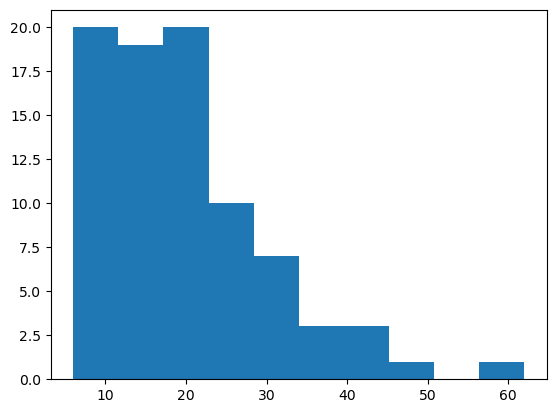

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.hist(survey['length'])
plt.show()

# 의견은 10-20자가 제일 많습니다.
# '역앞에 젊은이들이 모여있다'가 14글자(공백 포함)으로 비교적 간단한 의견이 많다는 것을 알 수 있습니다.

> ### 형태소 분석으로 문장 분해

In [8]:
# 문장의 특징을 파악하기 위해서는 어떤 단어가 포함되어 있는지를 이해해야 합니다.
# 문장 > 단어 분할하는 기술을 '형태소 분석'이라고 하며
# 대표적인 파이썬 라이브러리로는 konlpy가 있습니다.
# 이 라이브러리를 이용하면 문장의 단어들을 품사로 분해할 수 있습니다.

# * konlpy 환경 구축 - Java 기반

In [9]:
!java -version

openjdk version "11.0.13" 2021-10-19 LTS
OpenJDK Runtime Environment Corretto-11.0.13.8.1 (build 11.0.13+8-LTS)
OpenJDK 64-Bit Server VM Corretto-11.0.13.8.1 (build 11.0.13+8-LTS, mixed mode)


In [10]:
# !pip install JPype1==1.4.0

In [11]:
# java16버전 이상
# 시스템 환경 변수 설정
# 변수 이름 : JAVA_HOME
# 변수 값 : 자바 설치 경로 C:\Program Files\Amazon Corretto\jdk11.0.13_8

# Path 변수에 추가 : %JAVA_HOME%\bin

In [12]:
# anaconda


In [13]:
# !pip install konlpy

In [14]:
import sys
print("현재 Python 경로:", sys.executable) # conda

import jpype
print("JVM 경로:", jpype.getDefaultJVMPath())

# conda install이 자동으로 의존성 + 환경변수 설정까지 해줌
# conda는 Anaconda나 Miniconda에 포함된 패키지/환경 관리 도구입니다.
# 이를 이용하면 다른 프로젝트와 충돌 없이 각각 독립적인 파이썬 환경을 만들 수 있어요.

현재 Python 경로: c:\Users\chjin\anaconda3\python.exe
JVM 경로: C:\Users\chjin\corretto\jdk11.0.13_8\bin\server\jvm.dll


In [15]:
# 먼저 '형태소분석으로 문장을 분해해보자'라는 문장을 품사로 분해해 봅시다.
# conda 환경해서 실행 가능
from konlpy.tag import Okt

okt= Okt()
text = '형태소분석으로 문장을 분해해보자'
tagging= okt.pos(text)
# tagging

# 1행에서 konlpy 라이브러리를 불러오고 2행에서 초기화
# 3행에서 형태소 분석 할 문장을 지정하고 pos를 이용해 형태소 분석

# 출력 결과는 단어 및 품사가 리스트 형태로 표시됩니다.
# 단어만 따로 리스트형 변수에 저장해 봅시다.

In [16]:
words_to_parts= okt.pos(text)
words_to_parts

# words_to_parts : [(word, part)]

[('형태소', 'Noun'),
 ('분석', 'Noun'),
 ('으로', 'Josa'),
 ('문장', 'Noun'),
 ('을', 'Josa'),
 ('분해', 'Noun'),
 ('해보자', 'Verb')]

In [17]:
words_list = []
for word_and_part in words_to_parts :
  if word_and_part == 'EOS' : continue # 분석이 끝났다는 의미로 'EOS' 문자열이 들어있는 경우 때문
  word_tmp = word_and_part[0] # word
  words_list.append(word_tmp)

words_list

# 반복문을 이용해 [0]데이터 즉, 단어를 취득합니다.
# 첫 번째[1] 데이터에는 품사 정보가 들어 있습니다. 

['형태소', '분석', '으로', '문장', '을', '분해', '해보자']

> ### 특정 품사의 단어만 추출

In [18]:
# 형태소 분석의 품사 정보를 활용해서 문장에서 '동사', '명사'만 추출

test = '형태소분석으로 문장을 분해해보자'
parts= ['Noun', 'Verb']
words_to_parts = okt.pos(text)
words_list = []
for word_and_part in words_to_parts :
  if word_and_part == 'EOS' or word_and_part == '' : continue
  word_tmp = word_and_part[0]
  part = word_and_part[1]
  if not (part in parts) : continue
  words_list.append(word_tmp)

words_list

['형태소', '분석', '문장', '분해', '해보자']

In [19]:
# 품사가 명사나 동사가 아닌 단어는 continue에 의해 word_list에 저장되지 않습니다. 
# 앞의 결과와 달리 다섯 단어만 추출된 것을 알 수 있습니다.
# 이것으로 단어의 분할뿐만 아니라 *특정 단어만 추출*하는 것도 할 수 있게 됐습니다. 

# 문장의 특징을 파악하기 위해 형용사가 필요한 경우도 있고
# 노이즈를 피하기 위해 명사만 문장의 특징으로 하는 경우가 있습니다. 

# 여기서는 설문 결과에서 **어떤 단어가 사용되었을 때 만족도가 높은지** 살펴불 예정입니다.
# 이런 경우 명사만으로도 그 문장이 무엇을 서술하고 있는지 특정지을 수 있다고 생각할 수 있습니다. 
# 여기서부터는 _명사_만을 이용해서 survey 데이터를 분석합니다.

> ### 자주 나오는 명사 확인

In [20]:
# 전체 의견에 어떤 단어가 포함됐는지 파악
# survey 데이터의 comment 컬럼을 단어로 분해해서 all_words라는 변숭 전부 저장

all_nouns = []
parts = ['Noun']

for i in range(len(survey)) :
  word_part_list = okt.pos(survey['comment'].iloc[i])
  noun_list_tmp = [] # - 문장별로 단어를 모으고 싶을 때 유용 / extend 대신 append
  for word_part in word_part_list :
    if word_part == 'EOS' or word_part == '' : continue
    word_tmp = word_part[0]
    part_tmp = word_part[1]
    # if not (part in parts) : continue
    if part_tmp not in parts : continue
    noun_list_tmp.append(word_tmp) # 원소 추가
  all_nouns.extend(noun_list_tmp) # 리스트형끼리 결합

print(all_nouns)

# survey의 comment 칼럼을 for문으로 반복하며 형태소 분석을 실행
# 이 중 명사인 단어만 noun_list_tmp에 일시적으로 저장하고
# 이들을 extend로 리스트형끼리 결합해서 all_nouns에 저장

# '역앞'이라는 단어가 여러 개 존재합니다.
# 단어별 빈도수를 알아보기 위해 데이터 프레임에 저장하고 자주 나오는 단어 5개를 표시해 봅시다.



['역앞', '젊은이', '운동', '수', '장소', '것', '육아', '지원이', '어린이집', '바로', '입원', '수', '역앞', '상가', '생활', '놀', '장소', '놀', '장소', '상업시설', '좀', '더', '병원', '사이클링', '코스', '축제', '좀', '더', '성대', '초등학교', '공원', '더', '근처', '공원', '살기', '슈퍼', '육아', '데이트', '명소', '상가', '좀', '더', '밤길', '쓰레기', '처리', '영화관', '가로수', '더', '공원', '추가', '관광', '명소', '육아', '최고', '길이', '시내', '접근성', '집세', '합리', '의', '교통', '체증', '게', '해', '상가', '지붕', '비', '큰일', '상가', '더', '카페', '스포츠', '센터', '자주', '이용', '스포츠', '센터', '이용', '요금', '워킹맘', '지원', '더', '버스', '별로', '안', '자전거', '달리기', '달리기', '운동', '수', '장소', '기업', '역앞', '주차장', '아저씨', '말', '적', '경찰', '순찰', '더', '소방', '활동', '수', '재난', '시', '피난', '장소', '것', '요즘', '강', '범람', '피해', '크게', '이', '도시', '범람', '방지', '취하', '설명', '신호등', '사거리', '때문', '사고', '신호', '상가', '활성화', '활동', '좀더', '행정', '뒷받침', '아이', '놀', '장소', '역앞', '자전거', '주차장', '가로수', '낙엽', '청소', '가로수', '재해', '시', '비축', '상황', '보도', '길이', '수', '지역', '자치', '단체', '더', '지원', '자치', '단체', '활동', '안심', '살', '수', '관광지', '최근', '지방', '넘버', '치안', '제대로', '주차장', '수가', '요금'

In [21]:
# 자주 나오는 단어 5개

# count : 1(1을 len만큼 생성)
all_noun_df = pd.DataFrame({'words' : all_nouns, 'count' : len(all_nouns) * [1]})
all_noun_df

all_noun_group_df = all_noun_df.groupby('words').sum()
all_noun_group_df

all_noun_group_df.sort_values(by= 'count', ascending= False, inplace= True)
all_noun_group_df.head()

# 1행에서는 단어와 빈도수를 데이터프레ㅣㅇㅁ에 저장
# 이 때 count 컬럼에 전부 1을 대입
# 2행에서는 단어마다 count를 합함

# 그 결과 '더', '수', '장소', '주차장', '좀'이 많이 등장했으며
# 이 단어가 포함된 의견이 많다는 것을 알 수 있습니다.

# 여기서 14번 나온 '더', 7번 나온 '수', 그리고 '좀'이라는 단어들은
# 명사만 추출해도 노이즈 단어가 포함되는 것을 알 수 있습니다.abs
# 이 다음 단계에서는 '더', '수', '좀', 을 대상으로 제거해 보겠습니다.

,count
words,
더,14
수,7
장소,6
주차장,5
좀,5


> ### 관게없는 단어 제거

In [22]:
# 관계없는 단어를 제거하는 여러 방법이 있지만 
# 형태소 해석을 할 때 포함되지 않게 하는 것이 가장 간단합니다.
# 품사에서 특정 품사만 추출하는 것과 거의 같은 처리입니다.

stop_words = ['더', '수', '좀']
parts = ['Noun']
all_nouns = []

for i in range(len(survey)) :
  words_parts = okt.pos(survey['comment'].iloc[i])
  noun_list_tmp = [] # - 문장별로 단어를 모으고 싶을 때 유용 / extend 대신 append
  for word_part in words_parts :
    if word_part == 'EOS' or word_part == '' : continue
    word_tmp = word_part[0]
    part_tmp = word_part[1]
    if part_tmp not in parts : continue
    if word_tmp in stop_words : continue
    noun_list_tmp.append(word_tmp)
  
  all_nouns.extend(noun_list_tmp)

print(all_nouns)

# stop_words를 정의해서 제외 키워드를 설정
# 유지보수를 생각하면 엑셀과 같은 파일로 제외 키워드를 관리하고
# 파일을 불러들여 제외 키워드를 정의하는 것도 좋은 방법입니다.

# 그럼 stop_words를 제외한 명사만 데이터 프레임에 저장하고 많이 나오는 단어를 표시해 봅시다.


['역앞', '젊은이', '운동', '장소', '것', '육아', '지원이', '어린이집', '바로', '입원', '역앞', '상가', '생활', '놀', '장소', '놀', '장소', '상업시설', '병원', '사이클링', '코스', '축제', '성대', '초등학교', '공원', '근처', '공원', '살기', '슈퍼', '육아', '데이트', '명소', '상가', '밤길', '쓰레기', '처리', '영화관', '가로수', '공원', '추가', '관광', '명소', '육아', '최고', '길이', '시내', '접근성', '집세', '합리', '의', '교통', '체증', '게', '해', '상가', '지붕', '비', '큰일', '상가', '카페', '스포츠', '센터', '자주', '이용', '스포츠', '센터', '이용', '요금', '워킹맘', '지원', '버스', '별로', '안', '자전거', '달리기', '달리기', '운동', '장소', '기업', '역앞', '주차장', '아저씨', '말', '적', '경찰', '순찰', '소방', '활동', '재난', '시', '피난', '장소', '것', '요즘', '강', '범람', '피해', '크게', '이', '도시', '범람', '방지', '취하', '설명', '신호등', '사거리', '때문', '사고', '신호', '상가', '활성화', '활동', '좀더', '행정', '뒷받침', '아이', '놀', '장소', '역앞', '자전거', '주차장', '가로수', '낙엽', '청소', '가로수', '재해', '시', '비축', '상황', '보도', '길이', '지역', '자치', '단체', '지원', '자치', '단체', '활동', '안심', '살', '관광지', '최근', '지방', '넘버', '치안', '제대로', '주차장', '수가', '요금', '역', '앞', '공공', '주차장', '보행자', '용', '신호', '노인', '어린이', '생각', '설정', '급행', '시내', '버스', '노선'

In [23]:
all_nouns_df = pd.DataFrame({'word' : all_nouns, 'count' : len(all_nouns) * [1]})
all_nouns_df.head()

all_noun_group_df = all_nouns_df.groupby('word').sum()
all_noun_group_df.head()

all_noun_group_df.sort_values(by= 'count', ascending= False, inplace= True)
all_noun_group_df.head()

# 실행 결과, 이전과 달리 '더, 수, 좀'이라는 단어는 없어지고
# '장소', '주차장' 키워드가 상위로 올라오고
# '상가', '역앞', '공원'이 새로 등장했습니다.
# 이를 통해 제외 키워드가 제거된 것을 확인했습니다. 

# 그렇다면 '역앞'이라는 단어가 많은 의견에 포함되었는데
# **이것이 긍정적인 내용인지** 알아볼까요?

# 자주 나오는 단어와 고객 만족도의 관계를 살펴봅시다.


,count
word,
장소,6
주차장,5
상가,5
역앞,5
공원,5


> ### 자주 나오는 단어와 고객만족도의 관계

In [24]:
# 자주 나오는 단어와 고객 만족도의 관계를 알아보기 위해서는
# comment 칼럼을 불러와서 형태소 분석을 한 단어와 고객 만족도를 연결해야 합니다. 
# 형태소 분석을 하면서 고객만족도를 satisfaction이라는 변수에 저장합시다.

stop_words = ['더', '수', '좀']
parts = ['Noun']

all_nouns = []
satisfaction = []

for i in range(len(survey)) :
  words_parts = okt.pos(survey['comment'].iloc[i])
  # nouns_list_tmp = []  # - 문장별로 단어를 모아두고 싶을 때 유용
  for word_part in words_parts :
    if word_part == 'EOS' or word_part == '' : continue
    word_tmp = word_part[0]
    part_tmp = word_part[1]
    if word_tmp in stop_words : continue
    if part_tmp not in parts : continue
    # nouns_list_tmp.append(word_tmp)
    all_nouns.append(word_tmp)
    satisfaction.append(survey['satisfaction'].iloc[i]) 
  # all_nouns.append(nouns_list_tmp) # > 문장별로 저장됨

print(all_nouns)

word_satisfaction_df = pd.DataFrame({'word' : all_nouns, 'count' : len(all_nouns) * [1],
                                     'satisfaction' : satisfaction})
word_satisfaction_df.info() # 결측치 없는 것 확인
word_satisfaction_df.head()

# all_nouns에 단어를 추가하는 아래에
# satisfaction 만족도를 추가하는 처리를 추가

# '역앞'이라는 단어의 '역앞에 젊은이가 모여있다'라는 의견의 만족도가 1이기 때문에
# satisfaction 컬럼에 1이 들어있는 것을 알 수 있습니다.

# word마다 집계해 봅시다. 
# satisfaction > 평균(mean), count > 합계(sum)
  

['역앞', '젊은이', '운동', '장소', '것', '육아', '지원이', '어린이집', '바로', '입원', '역앞', '상가', '생활', '놀', '장소', '놀', '장소', '상업시설', '병원', '사이클링', '코스', '축제', '성대', '초등학교', '공원', '근처', '공원', '살기', '슈퍼', '육아', '데이트', '명소', '상가', '밤길', '쓰레기', '처리', '영화관', '가로수', '공원', '추가', '관광', '명소', '육아', '최고', '길이', '시내', '접근성', '집세', '합리', '의', '교통', '체증', '게', '해', '상가', '지붕', '비', '큰일', '상가', '카페', '스포츠', '센터', '자주', '이용', '스포츠', '센터', '이용', '요금', '워킹맘', '지원', '버스', '별로', '안', '자전거', '달리기', '달리기', '운동', '장소', '기업', '역앞', '주차장', '아저씨', '말', '적', '경찰', '순찰', '소방', '활동', '재난', '시', '피난', '장소', '것', '요즘', '강', '범람', '피해', '크게', '이', '도시', '범람', '방지', '취하', '설명', '신호등', '사거리', '때문', '사고', '신호', '상가', '활성화', '활동', '좀더', '행정', '뒷받침', '아이', '놀', '장소', '역앞', '자전거', '주차장', '가로수', '낙엽', '청소', '가로수', '재해', '시', '비축', '상황', '보도', '길이', '지역', '자치', '단체', '지원', '자치', '단체', '활동', '안심', '살', '관광지', '최근', '지방', '넘버', '치안', '제대로', '주차장', '수가', '요금', '역', '앞', '공공', '주차장', '보행자', '용', '신호', '노인', '어린이', '생각', '설정', '급행', '시내', '버스', '노선'

,word,count,satisfaction
0,역앞,1,1
1,젊은이,1,1
2,운동,1,5
3,장소,1,5
4,것,1,5


In [25]:
word_satisfaction_df.head()
word_satisfaction_mean_df = word_satisfaction_df.groupby('word')['satisfaction'].mean()
word_count_sum_df = word_satisfaction_df.groupby('word')['count'].sum()

# **만족도-count 결합**
word_df = pd.concat([word_satisfaction_mean_df, word_count_sum_df], axis= 1)
word_df.head()

# 첫 5행을 표시하면 '가로수' 외에는 모두 카운트가 1로 한 번 나온 단어가 출력됨
# 이는 소수 의견이므로 count가 3이상인 데이터만 뽑아서
# 고객 만족도를 내림차순 & 오름차순으로 5개씩 나열해 봅시다.

,satisfaction,count
word,,
가로수,1.666667,3
강,3.000000,1
거리,5.000000,1
걱정,2.000000,1
걸,2.000000,1


In [26]:
from IPython.display import display


freq_word_df = word_df[word_df['count'] >= 3]
freq_word_df.head()

freq_word_df.sort_values('satisfaction', ascending= False, inplace= True)
display(freq_word_df.head())
print()

freq_word_df.sort_values('satisfaction', ascending= True, inplace= True)
display(freq_word_df.head())

# 1) words_df에서 count 3이상 데이터 추출
# 2) satisfaction 상위 5개
# 3) satisfaction 하위 5개

# 만족도가 높은 키워드 : '육아', '관공서'
# 만족도가 낮은 키워드 : '주차장', '역앞' 
# 어떤 거리인지 보이기 시작합니다. 

C:\Users\chjin\AppData\Local\Temp\ipykernel_19912\125503266.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_word_df.sort_values('satisfaction', ascending= False, inplace= True)


,satisfaction,count
word,,
육아,4.333333,3
관공서,3.500000,4
길이,3.500000,4
활동,3.333333,3
장소,3.000000,6


C:\Users\chjin\AppData\Local\Temp\ipykernel_19912\125503266.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_word_df.sort_values('satisfaction', ascending= True, inplace= True)


,satisfaction,count
word,,
주차장,1.000000,5
역앞,1.200000,5
가로수,1.666667,3
놀,2.000000,3
지원,2.000000,3


In [27]:
# 마지막 남은 테크닉은 비슷한 문장 검색하기 입니다. 

# 좀 더 깊이 있는 분석을 위해서는 의견 하나하나를 살펴봐야 합니다 
# **인상적인 의견**이 있을 때는 **비슷한 의견**이 있는지
# **그 때의 만족도**는 어떤지 등 좀 더 깊게 조사합니다.  

# 이를 위해 문장의 특징을 표현하고 그 특징을 바탕으로 비슷한 문장을 특정하는 기술에 도전합니다.  


> ### 의견을 특징으로 표현

In [37]:
# survey.info()

In [ ]:
# 의견을 특징으로 표현하는 가장 기본적인 방법은 숫자 기반 방법으로
# 어떤 단어가 포함되어 있는지를 특징으로 정의합니다.
# ex. 역앞에 젊은이들이 모여있다 > '역앞', '젊은이' - 플래그

parts = ['Noun']
all_words_df = pd.DataFrame()
satisfaction = []

for i in range(len(survey)) :  
  tmp_words_df = pd.DataFrame()
  for word_part in okt.pos(survey['comment'].iloc[i]) :
    if word_part == 'EOS' or word_part == '' : continue 
    word = word_part[0]
    part = word_part[1]
    if part not in parts : continue 
    tmp_words_df[word] = [1] # 1이 아닌 [1] > 행이 없기 때문
    # all_words_df를 기준으로 tmp_words_df를 행 기준(아래로 이어붙임)으로 병합해야 함
  all_words_df = pd.concat([all_words_df, tmp_words_df], axis= 0, ignore_index= True)

# 행을 기준으로 병합
# 0~83 survey 결과
all_words_df.info() # 84행, 187열 - survey > 84문장, 187개의 단어(중복 없이)
all_words_df.head()

# tmp_words_df[word] = [1]로 문장에 단어가 포함되어 있으면 숫자 1을 대입
# 모든 의견마다 진행하고 concat으로 결합
# > 의견에 포함된 단어에는 1, 그 외에는 결측치가 대입됩니다. 
# 실제로 1행 데이터인 '역앞' 열에는 1이 있는 것을 알 수 있습니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Columns: 187 entries, 역앞 to 놀이기구
dtypes: float64(187)
memory usage: 122.8 KB


,역앞,젊은이,운동,수,장소,것,육아,지원이,어린이집,바로,...,걸,야간,불안,고령자,운동장,잔디밭,아주,설문지,투고,놀이기구
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# 결측치 0 대입
all_words_df = all_words_df.fillna(0)

# 각 의견의 특징이 작성되었습니다
# 1행의 데이터에 '역앞', 젋은이'에는 1이 그 외에는 0이 들어 있습니다.
print(survey['comment'].iloc[0])
all_words_df.head()


역앞에 젊은이들이 모여있다


,역앞,젊은이,운동,수,장소,것,육아,지원이,어린이집,바로,...,걸,야간,불안,고령자,운동장,잔디밭,아주,설문지,투고,놀이기구
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> ### 유사 의견 검색

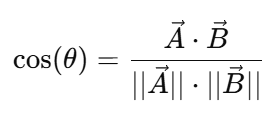

In [ ]:
# 타깃 의견 결정
# 만족도가 높은 '육아' 키워드를 포함하는
# '육아 지원이 좋다'와 비슷한 설문지를 찾아봅시다.

print(survey['comment'].iloc[2])
target_text = all_words_df.iloc[2] # 2번째 문장에 포함된 단어 : 열, 값 : 플래그(0, 1)
target_text # 단어 0.0 / 1.0

# 유사도 검색
# *문서의 유사도*를 지표로 하는 대표적인 수법인 '코사인 유사도' 
# 특징량까지의 각도로 유사도를 나타냄

cos_sim = []
for i in range(len(all_words_df)) :
  cos_text = all_words_df.iloc[i]
  # np.dot : 내적
  # np.linalg.norm : 길이/크기
  cos = np.dot(target_text, cos_text) / (np.linalg.norm(target_text) * np.linalg.norm(cos_text))
  cos_sim.append(cos) # 문장별 타깃 문장과의 코사인 유사도

all_words_df['cos_sim'] = cos_sim
all_words_df.sort_values('cos_sim', ascending= False).head()

# 전체 의견에 대해 타깃 의견과의 코사인 유사도를 계산하고
# 결과를 cos_sim이라는 변수에 저장


육아 지원이 좋다


C:\Users\chjin\AppData\Local\Temp\ipykernel_19912\3330445214.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_words_df['cos_sim'] = cos_sim


,역앞,젊은이,운동,수,장소,것,육아,지원이,어린이집,바로,...,야간,불안,고령자,운동장,잔디밭,아주,설문지,투고,놀이기구,cos_sim
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
15,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.707107
24,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000
55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
# 상위 의견 표시

high_sim_df = all_words_df.sort_values('cos_sim', ascending= False).head()
high_sim_df = high_sim_df[high_sim_df['cos_sim'] > 0]
high_sim_df

for idx in high_sim_df.index :
  print(survey['comment'].iloc[idx])
  
# '육아 지원이 좋다'에 대해 육아와 관련이 있는 문장은 모두 유사 문자임을 확인
# 문장의 유사성을 활용하여 유사성이 높은 문장만 추출해서 
# 만족도와 고객의 성향을 분석하면 분석의 폭이 넓어지니 꼭 활용해 보세요.
  

육아 지원이 좋다
육아가 쉽다
육아하기에는 최고


In [71]:
# 실습
# 의견 내 단어별 등장 여부에 따른 플래그

parts = ['Noun']
sentence_flag_df = pd.DataFrame()
satisfaction = []

for i in range(len(survey)) :
  tmp_sentence_flag_df = pd.DataFrame()
  for word_part in okt.pos(survey['comment'].iloc[i]) :
    if word_part == 'EOS' or word_part == '' : continue 
    word = word_part[0]
    part = word_part[1]
    if part not in parts : continue 
    tmp_sentence_flag_df[word] = [1]
  sentence_flag_df = pd.concat([sentence_flag_df, tmp_sentence_flag_df], axis= 0, ignore_index= True)

sentence_flag_df.head()
sentence_flag_df.fillna(0, inplace= True)
sentence_flag_df.head()

,역앞,젊은이,운동,수,장소,것,육아,지원이,어린이집,바로,...,걸,야간,불안,고령자,운동장,잔디밭,아주,설문지,투고,놀이기구
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
parts = ['Noun']
sentence_word_df = pd.DataFrame()
satisfaction = []

word_flag_dict = {}
okt_sentence = []
for i in range(len(survey)) :
  tmp_word_list = []
  for word_part in okt.pos(survey['comment'].iloc[i]) :
    if word_part == 'EOS' or word_part == '' : continue 
    word = word_part[0]
    part = word_part[1]
    if part not in parts : continue
    word_flag_dict[word] = 1 
    tmp_word_list.append(word)
  okt_sentence.append(tmp_word_list)

# word_flag_dict
# len(word_flag_dict) # 187
# okt_sentence
# len(okt_sentence) # 84 